# Figure XX - blast cassettes
Tested in 293Ts, 20k cells/well at 96-well scale \ 
Sparsely labeled eGFP cells \ 
Infected at 6-well scale \
Reseed at 20k/well into antibiotic conditions \
Media change every other day \
Flow on 10 dpi \



Reps:
- 2026.06.10: 3 reps Blast
- 2026.06.13: 1 rep


In [1]:
import rushd as rd
import matplotlib
import pandas as pd
import numpy as np
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt
from textwrap import wrap
from statannotations.Annotator import Annotator
from pathlib import Path
from scipy.optimize import curve_fit
from scipy.stats import poisson
from matplotlib.patches import Patch

In [7]:
alpha_tech_rep = 0.45
alpha_mean = 0.75
markersize = 7

## Load in data

In [2]:
# Set paths to the experiment folder and where to find the data
base_path = rd.datadir/'data'/'attune'/'Mary'

Plates = {'2026.06.10_exp48_blast': ['Plate1', 'Plate2', 'Plate3', 'Plate4'],
          '2026.06.13_exp53_blast': ['Plate1']
          
}

exp_path = []
yaml_path = []

for i in Plates:
    for j in Plates[i]:
        exp_path.append(base_path/i/j/'export_singlets')
        yaml_path.append(base_path/i/j/'export_singlets'/'well_metadata.yaml')

output_path = rd.rootdir/'output'/'Figure_XX_blast_cassettes'
cache_path = rd.rootdir/'output'/'Figure_XX_blast_cassettes'/'data.gzip'

plates_dict = pd.DataFrame({
    'data_path' : [exp for exp in exp_path],
    'yaml_path' : [yaml for yaml in yaml_path]
})

display(plates_dict)

,data_path,yaml_path
0,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...
1,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...
2,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...
3,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...
4,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...


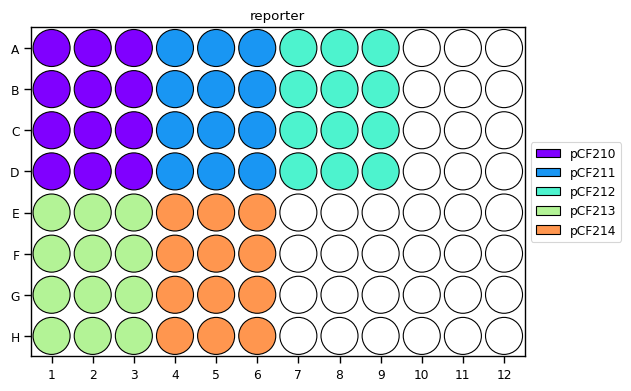

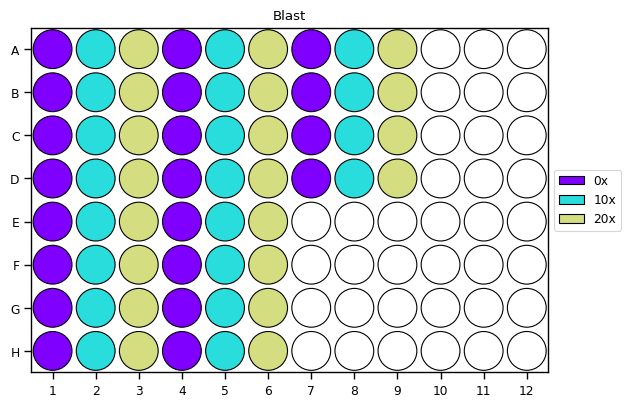

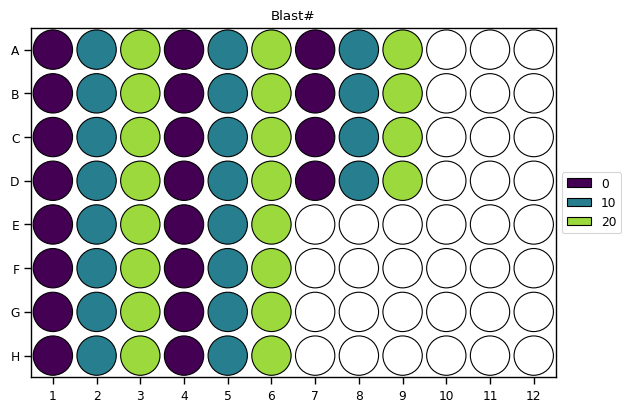

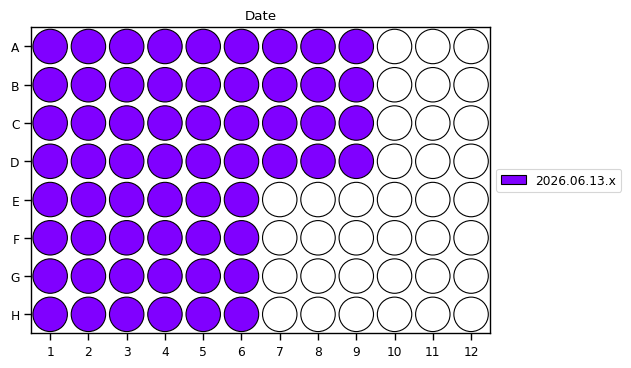

In [3]:
rd.plot.plot_well_metadata(plates_dict['yaml_path'].loc[4])

In [3]:
#Load data
data = pd.DataFrame()
if cache_path.is_file(): data = pd.read_parquet(cache_path)
else:
    channel_list = ['mGL-H','mGL-A', 'iRFP670-A','iRFP670-H', 'FSC-A', 'SSC-A']
    data = rd.flow.load_groups_with_metadata(plates_dict,columns=channel_list) #Could add in columns=channel_list here to get specific columns

    # Remove NaN values
    data.dropna(inplace=True)

    # Save data in the cache path for easier loading next time
    data.to_parquet(rd.outfile(cache_path))


In [4]:
data['conds'] = data['reporter'] +'.'+ data['Blast'] 
display(data)

,reporter,Blast,Blast#,Date,well,population,FSC-A,SSC-A,mGL-A,mGL-H,iRFP670-A,iRFP670-H,conds
0,pCF210,0x,0,2026.06.10.x,A1,Single Cells,381172.0,180511,18235.0,11984.0,-53,55,pCF210.0x
1,pCF210,0x,0,2026.06.10.x,A1,Single Cells,241005.0,99856,-15.0,50.0,80,54,pCF210.0x
2,pCF210,0x,0,2026.06.10.x,A1,Single Cells,222283.0,356135,195.0,158.0,1055,794,pCF210.0x
3,pCF210,0x,0,2026.06.10.x,A1,Single Cells,459088.0,272115,-62.0,74.0,52,90,pCF210.0x
4,pCF210,0x,0,2026.06.10.x,A1,Single Cells,417572.0,186680,72.0,59.0,36,62,pCF210.0x
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19599995,pCF214,20x,20,2026.06.13.x,H6,Single Cells,339211.0,322791,2814.0,1866.0,94,132,pCF214.20x
19599996,pCF214,20x,20,2026.06.13.x,H6,Single Cells,385711.0,175649,124.0,193.0,22,67,pCF214.20x
19599997,pCF214,20x,20,2026.06.13.x,H6,Single Cells,578102.0,322750,2986.0,2047.0,318,110,pCF214.20x
19599998,pCF214,20x,20,2026.06.13.x,H6,Single Cells,324463.0,480041,4849.0,3275.0,179,131,pCF214.20x


## Gating

c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_28628\3076871475.py:20: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


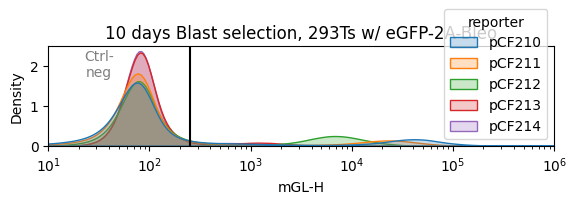

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(6, 2))

# Threshold for mGL
mGL_thresh = 2.5e2

x = 'mGL-H'
hue = 'reporter'
hue_order = ['pCF210', 'pCF211', 'pCF212', 'pCF213', 'pCF214']

untransfected = data[data['reporter'] == 'Untransfected']
data_now = data[(data['Blast'] == '0x') & (data['reporter'] != 'Untransfected') & (data[x] > 0)]

sns.kdeplot(data=data_now,
        ax=ax, x=x, hue=hue,
        hue_order=hue_order,
        common_norm=False, log_scale=(True, False),
        fill=True)

# Plot neg ctrl
sns.kdeplot(
    data=untransfected,
    ax=ax, x=x,
    common_norm=False, log_scale=(True, False),
    fill=False, linestyle='--', color='grey', legend=False)
ax.annotate('Ctrl-\nneg', (0.1, 0.7), color='grey', xycoords='axes fraction', ha='center')

# Plot threshold
ax.axvline(mGL_thresh, 0, 1, color='black')

# Move legend
# h,l = ax.get_legend_handles_labels()
# sns.move_legend(ax, handles=h, labels=l,
#     title='', loc='upper left', bbox_to_anchor=(1,1), frameon=False)

# Title
plt.title('10 days Blast selection, 293Ts w/ eGFP-2A-Bleo')
# Adjust limits
mRuby2_lim = (10, 1*10**6)
for sub_ax in plt.gcf().get_axes():
    sub_ax.set_xlim(mRuby2_lim)

# Misc plotting stuff
fig.tight_layout()  # Helps improve white spacing
# plt.savefig(figpath + 'dist-iRFP670.svg', bbox_inches='tight')

## Histograms

c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_ke

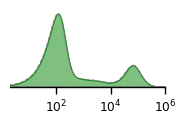

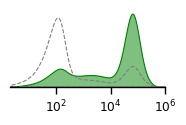

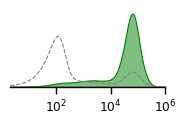

In [ ]:
reporters = np.array(['pCF210'])
parameters = pd.array(['mGL-A', 'TagBFP-A'])
plottitle = np.array(['0x_210.svg', '0_5x_210.svg', '1x_210.svg'])
puro = np.array(['0x', '10x', '20x'])

xsize = 2; ysize = 1; figsize = (xsize, ysize)
untransfected = data[data['reporter'] == 'Untransfected']
for j in range(3):
    plt.figure(figsize=figsize)
    underlay = data[(data['reporter'] == 'pCF210') & (data['Blast'] == '0x')& (data[parameters[0]] > 0)]
    data_now = data[(data['reporter'] == reporters[0]) & (data['Blast']==puro[j])& (data[parameters[0]] > 0)]
    g = sns.kdeplot(data=data_now, x=parameters[0],y=None,hue='conds', legend=False,
                    log_scale=True,fill=True, alpha = 0.5,common_norm=False,palette=['green'])
    g = sns.kdeplot(data=underlay, x=parameters[0],y=None,hue='conds', legend=False,
                    log_scale=True,fill=True, alpha = 0,common_norm=False,palette=['grey'], linestyle = '--')
    g.spines['left'].set_visible(False)
    plt.gca().get_yaxis().set_visible(False)
    plt.gca().set_xlabel("")
    g.set_xlim(xmin=2, xmax=10**6)
    g.spines['top'].set_visible(False)
    g.spines['right'].set_visible(False)
    g = g.get_figure()
    g.savefig(rd.outfile(output_path/plottitle[j]),bbox_inches='tight')

c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_ke

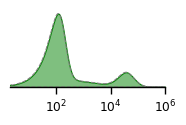

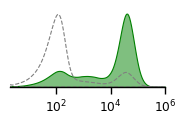

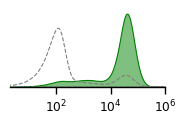

In [ ]:
reporters = np.array(['pCF211'])
parameters = pd.array(['mGL-A', 'TagBFP-A'])
plottitle = np.array(['0x_211.svg', '10x_211.svg', '20x_211.svg'])
puro = np.array(['0x', '10x', '20x'])

xsize = 2; ysize = 1; figsize = (xsize, ysize)
untransfected = data[data['reporter'] == 'Untransfected']
for j in range(3):
    plt.figure(figsize=figsize)
    underlay = data[(data['reporter'] == reporters[0]) & (data['Blast'] == '0x')& (data[parameters[0]] > 0)]
    data_now = data[(data['reporter'] == reporters[0]) & (data['Blast']==puro[j])& (data[parameters[0]] > 0)]
    g = sns.kdeplot(data=data_now, x=parameters[0],y=None,hue='conds', legend=False,
                    log_scale=True,fill=True, alpha = 0.5,common_norm=False,palette=['green'])
    g = sns.kdeplot(data=underlay, x=parameters[0],y=None,hue='conds', legend=False,
                    log_scale=True,fill=True, alpha = 0,common_norm=False,palette=['grey'], linestyle = '--')
    g.spines['left'].set_visible(False)
    plt.gca().get_yaxis().set_visible(False)
    plt.gca().set_xlabel("")
    g.set_xlim(xmin=2, xmax=10**6)
    g.spines['top'].set_visible(False)
    g.spines['right'].set_visible(False)
    g = g.get_figure()
    g.savefig(rd.outfile(output_path/plottitle[j]),bbox_inches='tight')

c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_ke

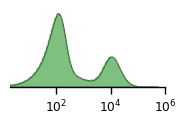

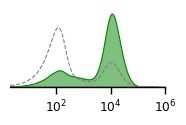

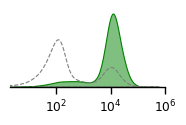

In [ ]:
reporters = np.array(['pCF212'])
parameters = pd.array(['mGL-A', 'TagBFP-A'])
plottitle = np.array(['0x_212.svg', '10x_212.svg', '20x_212.svg'])
puro = np.array(['0x', '10x', '20x'])

xsize = 2; ysize = 1; figsize = (xsize, ysize)
untransfected = data[data['reporter'] == 'Untransfected']
for j in range(3):
    plt.figure(figsize=figsize)
    underlay = data[(data['reporter'] == reporters[0]) & (data['Blast'] == '0x') & (data[parameters[0]] > 0)]
    data_now = data[(data['reporter'] == reporters[0]) & (data['Blast']==puro[j]) & (data[parameters[0]] > 0)]
    g = sns.kdeplot(data=data_now, x=parameters[0],y=None,hue='conds', legend=False,
                    log_scale=True,fill=True, alpha = 0.5,common_norm=False,palette=['green'])
    g = sns.kdeplot(data=underlay, x=parameters[0],y=None,hue='conds', legend=False,
                    log_scale=True,fill=True, alpha = 0,common_norm=False,palette=['grey'], linestyle = '--')
    g.spines['left'].set_visible(False)
    plt.gca().get_yaxis().set_visible(False)
    plt.gca().set_xlabel("")
    g.set_xlim(xmin=2, xmax=10**6)
    g.spines['top'].set_visible(False)
    g.spines['right'].set_visible(False)
    g = g.get_figure()
    g.savefig(rd.outfile(output_path/plottitle[j]),bbox_inches='tight')

c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_ke

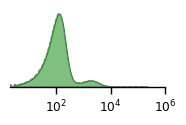

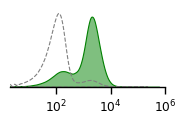

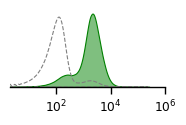

In [ ]:
reporters = np.array(['pCF213'])
parameters = pd.array(['mGL-A', 'TagBFP-A'])
plottitle = np.array(['0x_213.svg', '10x_213.svg', '20x_213.svg'])
puro = np.array(['0x', '10x', '20x'])

xsize = 2; ysize = 1; figsize = (xsize, ysize)
untransfected = data[data['reporter'] == 'Untransfected']
for j in range(3):
    plt.figure(figsize=figsize)
    underlay = data[(data['reporter'] == reporters[0]) & (data['Blast'] == '0x')& (data[parameters[0]] > 0)]
    data_now = data[(data['reporter'] == reporters[0]) & (data['Blast']==puro[j])& (data[parameters[0]] > 0)]
    g = sns.kdeplot(data=data_now, x=parameters[0],y=None,hue='conds', legend=False,
                    log_scale=True,fill=True, alpha = 0.5,common_norm=False,palette=['green'])
    g = sns.kdeplot(data=underlay, x=parameters[0],y=None,hue='conds', legend=False,
                    log_scale=True,fill=True, alpha = 0,common_norm=False,palette=['grey'], linestyle = '--')
    g.spines['left'].set_visible(False)
    plt.gca().get_yaxis().set_visible(False)
    plt.gca().set_xlabel("")
    g.set_xlim(xmin=2, xmax=10**6)
    g.spines['top'].set_visible(False)
    g.spines['right'].set_visible(False)
    g = g.get_figure()
    g.savefig(rd.outfile(output_path/plottitle[j]),bbox_inches='tight')

c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_ke

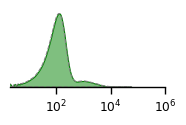

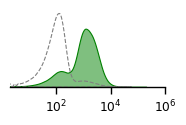

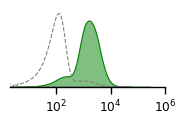

In [ ]:
reporters = np.array(['pCF214'])
parameters = pd.array(['mGL-A', 'TagBFP-A'])
plottitle = np.array(['0x_214.svg', '10x_214.svg', '20x_214.svg'])
puro = np.array(['0x', '10x', '20x'])

xsize = 2; ysize = 1; figsize = (xsize, ysize)
untransfected = data[data['reporter'] == 'Untransfected']
for j in range(3):
    plt.figure(figsize=figsize)
    underlay = data[(data['reporter'] == reporters[0]) & (data['Blast'] == '0x')& (data[parameters[0]] > 0)]
    data_now = data[(data['reporter'] == reporters[0]) & (data['Blast']==puro[j])& (data[parameters[0]] > 0)]
    g = sns.kdeplot(data=data_now, x=parameters[0],y=None,hue='conds', legend=False,
                    log_scale=True,fill=True, alpha = 0.5,common_norm=False,palette=['green'])
    g = sns.kdeplot(data=underlay, x=parameters[0],y=None,hue='conds', legend=False,
                    log_scale=True,fill=True, alpha = 0,common_norm=False,palette=['grey'], linestyle = '--')
    g.spines['left'].set_visible(False)
    plt.gca().get_yaxis().set_visible(False)
    plt.gca().set_xlabel("")
    g.set_xlim(xmin=2, xmax=10**6)
    g.spines['top'].set_visible(False)
    g.spines['right'].set_visible(False)
    g = g.get_figure()
    g.savefig(rd.outfile(output_path/plottitle[j]),bbox_inches='tight')

## eGFP Gating

**EGFP Threshold**

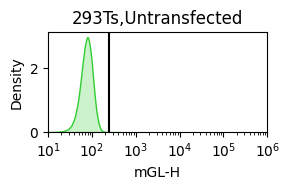

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(3, 2))

# Threshold for GFP
eGFP_H_thresh = 250

# Plot eGFP-H
x = 'mGL-H'

# Plot Ctrl-EGFP
cond = 'Untransfected'
sns.kdeplot(data=data.loc[(data['reporter'] == cond) & (data[x] > 0)],
        ax=ax, x=x,
        common_norm=False, log_scale=(True, False), color='limegreen',
        fill=True)

# Plot neg ctrl
# sns.kdeplot(
#     data=untransfected,
#     ax=ax, x=x,
#     common_norm=False, log_scale=(True, False),
#     fill=False, linestyle='--', color='grey', legend=False)
# ax.annotate('Ctrl-\nneg', (0.3, 0.7), color='grey', xycoords='axes fraction', ha='center')


# Plot threshold
ax.axvline(eGFP_H_thresh, 0, 1, color='black')

# Title
plt.title(f'293Ts,{cond}')
# Adjust limits
eGFP_lim = (10, 1*10**6)
for sub_ax in plt.gcf().get_axes():
    sub_ax.set_xlim(eGFP_lim)

# Misc plotting stuff
fig.tight_layout()  # Helps improve white spacing
# plt.savefig(figpath + 'dist-eGFP.svg', bbox_inches='tight')

In [9]:
# Categorize cells based on eGFP_thresh
data.loc[:, 'eGFP_cat'] = 'eGFP-'
data.loc[(data['mGL-H'] > eGFP_H_thresh), 'eGFP_cat'] = 'eGFP+'

# Gate infected cells
df_use = data.copy()

# Get total counts and percent of GFP-H+ of the infected cells
group = [ 'reporter', 'conds', 'Date', 'Blast']
count_df_reps = df_use.groupby([*group, 'well', 'eGFP_cat'])[
    'mGL-H'].count().unstack(fill_value=0).stack().rename('count') # Puts 0 if no GFP-H+ rather than dropping row
percent_df_reps = (count_df_reps*100/count_df_reps.groupby([*group, 'well']).transform('sum')).reset_index(name='percent')
data_eGFP_count_reps = count_df_reps.reset_index()

# Extract just the eGFP+
data_eGFP_percent_reps = percent_df_reps.loc[(percent_df_reps['eGFP_cat'] == 'eGFP+')]
data_eGFP_count_reps = data_eGFP_count_reps.loc[(data_eGFP_count_reps['eGFP_cat'] == 'eGFP+')]

In [10]:
# Convert to dataframe
data_eGFP_count_reps = count_df_reps.reset_index()

# Calculate total cells per well
total_cells = (
    data_eGFP_count_reps
    .groupby([*group, 'well'])['count']
    .sum()
    .reset_index(name='total_cells')
)

# Add total_cells column
data_eGFP_count_reps = data_eGFP_count_reps.merge(
    total_cells,
    on=[*group, 'well'],
    how='left'
)

In [11]:
Blast_conds = ['0x', '10x', '20x']

## Dot plots

**(%) eGFP**

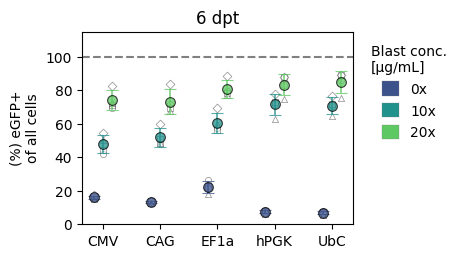

In [40]:
# General plotting params
x = 'reporter'
y = 'percent'
marker_list = ['o', 's', '^', 'D', 'P', 'X']   

order = ['pCF210', 'pCF211', 'pCF212', 'pCF213' , 'pCF214']

antibiotic_map = {
    'pCF210':'Blast',
    'pCF211':'Blast', 
    'pCF212': 'Blast',
    'pCF213': 'Blast',
    'pCF214': 'Blast'
}

label_map = {
    'pCF210':'CMV',
    'pCF211':'CAG', 
    'pCF212': 'EF1a',
    'pCF213': 'hPGK',
    'pCF214': 'UbC'
}

df_curr = data_eGFP_percent_reps[data_eGFP_percent_reps['reporter'].isin(order)].copy()

hue = 'Blast'

hue_order = Blast_conds

# Calculate biological replicate means


bio_means = (
    df_curr
    .groupby(['reporter','conds', 'Blast', 'Date'], as_index=False)['percent']
    .mean()
)

summary = (
    bio_means
    .groupby(['reporter','conds', 'Blast'], as_index=False)
    .agg(
        mean=('percent', 'mean'),
        sd=('percent', 'std'),
        sem=('percent', lambda x: x.std(ddof=1)/np.sqrt(len(x)))
    )
)


fig, ax = plt.subplots(1, 1, figsize=(3.5,2.5))

colors = sns.color_palette("viridis", len(hue_order))

# Horizontal offsets for each puro concentration
offsets = np.linspace(-0.04, 0.04, len(hue_order))
group_centers = np.linspace(0, 1 , len(order))


# Plot technical replicate means (one point per biological replicate)

for rep_idx, rep in enumerate(sorted(bio_means.Date.unique())):

    rep_data = bio_means[bio_means.Date == rep]

    for i, cond in enumerate(order):
        for j, puro in enumerate(hue_order):

            row = rep_data[
                (rep_data.reporter == cond) &
                (rep_data.Blast == puro)
            ]

            if row.empty:
                continue

            xloc = group_centers[i] + offsets[j]

            ax.scatter(
                xloc,
                row.percent.iloc[0],
                marker=marker_list[rep_idx],
                s=20,
                facecolors='white',
                edgecolors='black',
                linewidth=0.5,
                alpha=alpha_tech_rep,
                zorder=2
            )

# Plot biological replicate mean ± SD


for i, cond in enumerate(order):
    for j, puro in enumerate(hue_order):

        row = summary[
            (summary.reporter == cond) &
            (summary.Blast == puro)
        ]

        if row.empty:
            continue

        xloc = group_centers[i] + offsets[j]

        ax.errorbar(
            xloc,
            row['mean'].iloc[0],
            yerr=row['sd'].iloc[0],   # change to row['sem'] if desired
            fmt='o',
            markersize=markersize,
            color=colors[j],
            alpha=alpha_mean,
            mec='black',
            mew=0.8,
            capsize=4,
            lw=1.3,
            zorder=5
        )


ax.yaxis.set_label_text('(%) eGFP+\nof all cells')
ax.set_ylim((0,115))


legend_handles = [
    Patch(facecolor=color, edgecolor='grey',
          label=str(puro), linewidth=0.2)
    for color, puro in zip(colors, hue_order)
]

ax.legend(
    handles=legend_handles,
    title='Blast conc.\n[µg/mL]',
    loc='upper left',
    bbox_to_anchor=(1.02,1),
    frameon=False,
    handlelength=1.2,
    handleheight=1.2
)

ax.set_title('6 dpt')
ax.axhline(100, color='grey', linestyle='--')

ax.set_xlabel('')
ax.set_xticks(group_centers)
ax.set_xticklabels([label_map[l] for l in order])


plottitle = 'constitutive_blast_EGFP_purity_dot.svg'
plt.savefig(rd.outfile(output_path/plottitle),bbox_inches='tight')

**eGFP+ count**

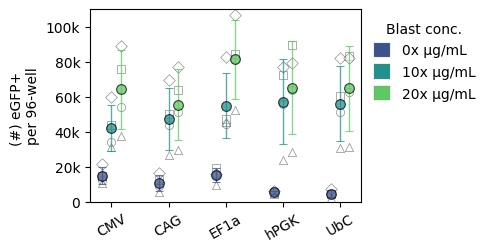

In [41]:
# General plotting params
x = 'reporter'
y = 'count'
marker_list = ['o', 's', '^', 'D', 'P', 'X']   

order = ['pCF210', 'pCF211', 'pCF212', 'pCF213' , 'pCF214']

antibiotic_map = {
    'pCF210':'Blast',
    'pCF211':'Blast', 
    'pCF212': 'Blast',
    'pCF213': 'Blast',
    'pCF214': 'Blast'
}

label_map = {
    'pCF210':'CMV',
    'pCF211':'CAG', 
    'pCF212': 'EF1a',
    'pCF213': 'hPGK',
    'pCF214': 'UbC'
}

df_curr = data_eGFP_count_reps[data_eGFP_count_reps['reporter'].isin(order) & (data_eGFP_count_reps['eGFP_cat'] == 'eGFP+')].copy()

hue = 'Blast'

hue_order = Blast_conds

# Calculate mean of biological replicate means

bio_means = (
    df_curr
    .groupby(['reporter','conds', 'Blast', 'Date'], as_index=False)[y]
    .mean()
)

summary = (
    bio_means
    .groupby(['reporter','conds', 'Blast'], as_index=False)
    .agg(
        mean=(y, 'mean'),
        sd=(y, 'std')
    )
)

fig, ax = plt.subplots(1, 1, figsize=(3.5,2.5))

colors = sns.color_palette("viridis", n_colors=len(hue_order))

# Technical replicate dots (back layer)

unique_dates = sorted(bio_means.Date.unique())
# Horizontal offsets for each puro concentration
offsets = np.linspace(-0.04, 0.04, len(hue_order))
group_centers = np.linspace(0, 1 , len(order))

markers = ['o', 's', '^', 'D', 'P', 'X']

for rep_idx, date in enumerate(unique_dates):

    rep_data = bio_means[bio_means.Date == date]

    for i, cond in enumerate(order):
        for j, puro in enumerate(hue_order):

            row = rep_data[
                (rep_data.reporter == cond) &
                (rep_data.Blast == puro)
            ]

            if row.empty:
                continue

            xloc = group_centers[i] + offsets[j]

            ax.scatter(
                xloc,
                row[y].iloc[0],
                marker=markers[rep_idx],
                s=35,
                facecolor='white',
                edgecolor='black',
                linewidth=0.5,
                alpha=alpha_tech_rep,
                zorder=2
            )

# Biological replicate mean dots (front layer)


for i, cond in enumerate(order):
    for j, puro in enumerate(hue_order):

        row = summary[
            (summary.reporter == cond) &
            (summary.Blast == puro)
        ]

        if row.empty:
            continue

        xloc = group_centers[i] + offsets[j]

        ax.errorbar(
            xloc,
            row['mean'].iloc[0],
            yerr=row['sd'].iloc[0],
            fmt='o',
            markersize=markersize,
            color=colors[j],
            alpha=alpha_mean,
            mec='black',
            mew=0.8,
            capsize=3,
            linewidth=1,
            zorder=5
        )

# Formatting

ax.yaxis.set_label_text('(#) eGFP+ \nper 96-well')
ax.xaxis.set_label_text('')
ax.set_ylim((0,110000))

ax.yaxis.set_major_formatter(
    matplotlib.ticker.FuncFormatter(
        lambda x, _: f'{x:.0f}' if abs(x) < 1000 else f'{x/1000:.0f}k'
    )
)

ax.set_xticks(group_centers)

ax.set_xticklabels(
    [label_map[t] for t in order],
    rotation=30
)


# Legend
legend_handles = [
    Patch(
        facecolor=colors[i],
        edgecolor='grey', linewidth = 0.2,
        label=f'{p} µg/mL'
    )
    for i, p in enumerate(hue_order)
]

ax.legend(
    handles=legend_handles,
    title='Blast conc.',
    loc='upper left',
    bbox_to_anchor=(1,1),
    frameon=False,
    handlelength=1.2,
    handleheight=1.2
)

plottitle = 'constitutive_blast_EGFP_count_dot.svg'
plt.savefig(rd.outfile(output_path/plottitle),bbox_inches='tight')